<a href="https://colab.research.google.com/github/ariannab02/Progetto-IntroDSePC-Gruppo-14/blob/Arianna/1_Progetto_IntroDSePC_gruppo_14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Progetto del corso - Introduzione alla Data Science e al Pensiero Computazionale - a.a. 2025/2026

# Membri del gruppo 14

Il gruppo 14 è composto da:

*   **Arianna Bertoldo:** matricola 1220440, email arianna.bertoldo@studio.unibo.it
*   **Veronica Contarin:** matricola 1233363, email veronica.contarin@studio.unibo.it


# Materiale del progetto

Il materiale del progetto è il seguente:
* Bank_Marketing.csv: il dataset contiene informazioni raccolte nel corso di attività di telemarketing svolte da un istituto bancario. Ogni record descrive un cliente e l'esito di una campagna di marketing volta a promuovere prodotti di conto deposito. L'obiettivo è quello di costruire modelli predittivi in grado di identificare i clienti che presentano una maggiore probabilità di sottoscrivere il prodotto finanziario offerto.
L'obiettivo della classificazione è prevedere se il cliente sottoscriverà un conto deposito a termine vincolato (variabile y).
* Bank_Marketing_Description: descrizione del dataset e delle variabili.

# Preparazione dell'ambiente

Prima di iniziare questa parte prepariamo l'ambiente Colab importando **Pandas**, **Seaborn** e **Scikit-learn**.

In [8]:
# Pandas
import pandas as pd
import numpy as np

# Seaborn
import seaborn as sns
import matplotlib.pyplot as plt

# Scikit-learn
from sklearn import svm, tree
from sklearn.metrics import *


# Fase 1

Carichiamo il dataset originale.

In [9]:
bank = pd.read_csv("Bank_Marketing.csv", sep=";")
print (bank)

       age           job   marital  education default  balance housing loan  \
0       58    management   married   tertiary      no     2143     yes   no   
1       44    technician    single  secondary      no       29     yes   no   
2       33  entrepreneur   married  secondary      no        2     yes  yes   
3       47   blue-collar   married    unknown      no     1506     yes   no   
4       33       unknown    single    unknown      no        1      no   no   
...    ...           ...       ...        ...     ...      ...     ...  ...   
45206   51    technician   married   tertiary      no      825      no   no   
45207   71       retired  divorced    primary      no     1729      no   no   
45208   72       retired   married  secondary      no     5715      no   no   
45209   57   blue-collar   married  secondary      no      668      no   no   
45210   37  entrepreneur   married  secondary      no     2971      no   no   

         contact  day month  duration  campaign  pd

## Input variables - bank client data:
1. age
2. job: type of job (admin., blue collar, entrepreneur, housemaid, management, retired, self-employed, services, student, technician, unemployed, unknown)
3. marital: marital status (married, single, divorced) - note: "divorced" means divorced or widowed
4. education: education level (primary, secondary, tertiary, unknown)
5. default: has credit in default?
6. balance: average yearly balance, in euros
7. housing: has housing loan?
8. loan: has personal loan?
9. contact: contact communication type (unknown, cellular, telephone)
10. day: last contact day of the month
 11. month: last contact month of year
  12. duration: last contact duration, in seconds
  13. campaign: number of contacts performed during this campaign and for this client
  14. pdays: number of days that passed by after the client was last contacted from a previous campaign, -1 means client was not previously contacted
  15. previous: number of contacts performed before this campaign and for this client
  16. poutcome: outcome of the previous marketing campaign
failure, success, other, unknown
  17. y - has the client subscribed a term deposit?


## ISTRUZIONI FASE 1

Obiettivo: prima analisi del dataset per comprenderne:
* struttura;
* distribuzioni;
* qualità;
* limiti;
* possibili problemi


Requisiti - almeno:
* 8 domande/ipotesi;
* 5 statistiche descrittive;
* 3 riflessioni critiche sui dati.


Esempi:
* class imbalance;
* outlier;
* feature correlate;
* dati mancanti;
* feature sospette.

## Domanda 1.1

Informazioni generiche sul dataset *Bank_Marketing*

In [10]:
bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [11]:
print("Le colonne sono:", bank.shape[1]) # quante colonne
print("Le righe sono:", bank.shape[0]) # quante righe

Le colonne sono: 17
Le righe sono: 45211


In [12]:
bank.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [13]:
bank.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


Categorie delle variabili nominali categoriche

In [14]:
for col in bank.select_dtypes(include='object').columns:
    print(col)
    print(bank[col].unique())
    print()

    #stampa le categorie delle variabili categoriche

job
['management' 'technician' 'entrepreneur' 'blue-collar' 'unknown'
 'retired' 'admin.' 'services' 'self-employed' 'unemployed' 'housemaid'
 'student']

marital
['married' 'single' 'divorced']

education
['tertiary' 'secondary' 'unknown' 'primary']

default
['no' 'yes']

housing
['yes' 'no']

loan
['no' 'yes']

contact
['unknown' 'cellular' 'telephone']

month
['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar' 'apr' 'sep']

poutcome
['unknown' 'failure' 'other' 'success']

y
['no' 'yes']



È possibile notare che:
* la variabile '*job*' ha ben 11 varianti (escludendo i valori mancanti '*unknown*')
* la variabile '*poutcome*' (l'effetto della precedente campagna marketing) contiene una variante '*other*' di cui non conosciamo il significato




---



In [15]:
bank[bank["duration"] > 3000]  ## questo non dovrebbe essere qui giusto?

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
2386,45,blue-collar,married,secondary,no,66,yes,no,unknown,13,may,3366,3,-1,0,unknown,no
4382,34,blue-collar,married,primary,no,183,yes,no,unknown,19,may,3078,4,-1,0,unknown,no
6451,44,services,divorced,secondary,no,51,yes,yes,unknown,27,may,3094,2,-1,0,unknown,yes
9947,59,management,married,secondary,no,1321,no,no,unknown,9,jun,3881,3,-1,0,unknown,yes
12347,28,admin.,single,secondary,no,-7,no,yes,unknown,26,jun,3183,2,-1,0,unknown,yes
19639,37,blue-collar,married,tertiary,no,359,no,yes,cellular,7,aug,3422,2,-1,0,unknown,no
21113,43,self-employed,married,tertiary,no,423,no,no,cellular,14,aug,3322,2,-1,0,unknown,no
24044,36,self-employed,single,tertiary,no,-103,yes,yes,telephone,17,oct,3253,1,-1,0,unknown,yes
24095,30,admin.,married,secondary,no,1310,no,no,telephone,27,oct,3284,1,-1,0,unknown,no
24148,59,technician,married,tertiary,no,6573,yes,no,telephone,10,nov,4918,1,-1,0,unknown,no


## Domanda 1.1.2

## Quanti sono i dati mancanti?

In [16]:
print(bank.isnull().sum())

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


Tramite questa analisi non risultano esserci dati mancanti. Tuttavia, come notato visivamente dalle prime righe del dataset, vi sono dei valori categorizzati come "unknown" e quindi di fatto mancanti.

In [17]:
unknown = (bank == "unknown").sum()

pd.DataFrame({
    "Mancanti": unknown,
    "Percentuale": (unknown / len(bank) * 100).round(1)
})

,Mancanti,Percentuale
age,0,0.0
job,288,0.6
marital,0,0.0
education,1857,4.1
default,0,0.0
balance,0,0.0
housing,0,0.0
loan,0,0.0
contact,13020,28.8
day,0,0.0


In [18]:
bank[bank["contact"] != "unknown"].head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
12657,27,management,single,secondary,no,35,no,no,cellular,4,jul,255,1,-1,0,unknown,no
12658,54,blue-collar,married,primary,no,466,no,no,cellular,4,jul,297,1,-1,0,unknown,no
12659,43,blue-collar,married,secondary,no,105,no,yes,cellular,4,jul,668,2,-1,0,unknown,no
12660,31,technician,single,secondary,no,19,no,no,telephone,4,jul,65,2,-1,0,unknown,no
12661,27,technician,single,secondary,no,126,yes,yes,cellular,4,jul,436,4,-1,0,unknown,no


'*contact*' assume un valore diverso da '*unknown*' solo a partire dalla riga 12.657, nel mese di luglio.

Notiamo che la maggioranza delle variabili **non** presenta valori mancanti, tuttavia:
* **i dati sui contatti dei clienti sono incompleti**, dal momento che vengono registrati solo a partire dal mese di luglio
* la variabile '*poutcome*', cioè **l'esito della precedente campagna pubblicitaria, è sconosciuto circa nell'80% dei casi**
* istruzione e lavoro presentano basse percentuali di dati mancanti, probabilmente non dichiarati dai clienti stessi

In [19]:
nuovi = (bank['previous'] == 0).sum()
nuovi_perc = (nuovi/len(bank)*100).round(2)
print("I clienti che non erano mai stati contattati prima sono", nuovi,".")
print("L'", nuovi_perc, "%", "del totale.")


I clienti che non erano mai stati contattati prima sono 36954 .
L' 81.74 % del totale.


Questo spiega la ragione dei dati mancanti nel caso di '*poutcome*', che descrive l'esito della campagna marketing precedente.





##Domanda xx (1.3)

##I cliente già contattati compaiono più volte nel dataset?



In [20]:
#idea nostra, codice ai

cols = [
    'age', 'job', 'marital', 'education',
    'default', 'balance', 'housing', 'loan'
]

duplicati = bank[bank.duplicated(subset=cols, keep=False)]
#un duplicato è una riga che ha cols uguali
#mantiene solo le righe duplicate


duplicati.sort_values(cols)
#ordina le colonne di modo che i valori identici
#a partire dalla colonna age siano conseguenti

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
40887,18,student,single,primary,no,608,no,no,cellular,12,aug,267,1,-1,0,unknown,yes
42274,18,student,single,primary,no,608,no,no,cellular,13,nov,210,1,93,1,success,yes
40744,18,student,single,unknown,no,108,no,no,cellular,10,aug,167,1,-1,0,unknown,yes
41487,18,student,single,unknown,no,108,no,no,cellular,8,sep,169,1,-1,0,unknown,yes
42954,18,student,single,unknown,no,108,no,no,cellular,9,feb,92,1,183,1,success,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45010,86,retired,married,primary,no,1255,no,no,cellular,14,oct,192,2,92,4,success,no
41934,92,retired,married,unknown,no,775,no,no,cellular,22,oct,313,3,-1,0,unknown,yes
42727,92,retired,married,unknown,no,775,no,no,cellular,26,jan,164,4,96,3,success,yes
44262,93,retired,married,unknown,no,775,no,no,cellular,22,jul,860,2,177,7,success,yes


In [21]:
duplicates = bank.duplicated().sum()
print(duplicates)

0


Sì, i clienti contattati più volte compaiono come righe diverse nel dataset:


* tuttavia **non si tratta di duplicati identici**, ma **differiscono** nelle variabili successive a 'duration'
* forniscono informazioni utili e non costituiscono un punto di debolezza del dataset, ma una risorsa informativa aggiuntiva


## Domanda xx (1.4)

##Qual è la condizione socio-economica del campione?

In [22]:
(bank['job'].value_counts(normalize=True) * 100).round(2)

,proportion
job,
blue-collar,21.53
management,20.92
technician,16.80
admin.,11.44
services,9.19
retired,5.01
self-employed,3.49
entrepreneur,3.29
unemployed,2.88


In [23]:
bank.groupby('job')['balance'].agg(
    media='mean',
    mediana='median',
    dev_standard='std',
    minimo='min',
    massimo='max',
).round(2).sort_values('mediana', ascending=False)


#named aggregation, richiama le funzioni sotto forma di stringhe

,media,mediana,dev_standard,minimo,massimo
job,,,,,
retired,1984.22,787.0,4397.04,-1598,81204
unknown,1772.36,677.0,2970.29,-295,19706
management,1763.62,572.0,3822.97,-6847,102127
unemployed,1521.75,529.0,3144.67,-1270,44134
self-employed,1647.97,526.0,3684.26,-3313,52587
student,1388.06,502.0,2441.70,-679,24025
technician,1252.63,421.0,2548.54,-2827,45248
housemaid,1392.40,406.0,2984.69,-1941,45141
admin.,1135.84,396.0,2641.96,-1601,64343


Le categorie lavorative più rappresentate, manager e operai, sono, com'è prevedibile, ai poli opposti della distribuzione.

In [24]:
(bank['marital'].value_counts(normalize=True) * 100).round(2)

,proportion
marital,
married,60.19
single,28.29
divorced,11.52


In [25]:
bank.groupby('marital')['balance'].agg(
    media='mean',
    mediana='median',
    dev_standard='std',
    minimo='min',
    massimo='max',
).round(2).sort_values('mediana', ascending=False)


,media,mediana,dev_standard,minimo,massimo
marital,,,,,
married,1425.93,477.0,3140.96,-6847,98417
single,1301.50,437.0,2875.32,-8019,102127
divorced,1178.87,348.0,2926.45,-4057,66721


In [26]:
bank['age_category'] = pd.cut(
    bank['age'],
    bins=[0, 30, 60, float('inf')],
    labels=['Under 30', '30-59', 'Over 60'],
    right=False #nell'intervallo è escluso il valore a destra
)

totali = bank['age_category'].value_counts()
frequenze = ((totali/len(bank))*100).round(2)


pd.DataFrame({
    'totali': totali,
    'percentuali': frequenze
})

,totali,percentuali
age_category,,
30-59,38154,84.39
Under 30,5273,11.66
Over 60,1784,3.95


In [27]:
bank.groupby('age_category')['balance'].agg(
    media='mean',
    mediana='median',
    dev_standard='std',
    minimo='min',
    massimo='max',
).round(2).sort_values('mediana', ascending=False)


/tmp/ipykernel_2133/3431944438.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bank.groupby('age_category')['balance'].agg(


,media,mediana,dev_standard,minimo,massimo
age_category,,,,,
Over 60,2458.62,1058.0,5071.70,-4057,81204
30-59,1362.93,449.5,3010.89,-6847,102127
Under 30,986.57,339.0,2155.62,-8019,36252


Notiamo che:
* le **categorie lavorative** più rappresentate sono gli *operai* (21,5%), i *manager* (20,9%) e i *tecnici* (16%), che insieme costituiscono poco più della metà della clientela totale (del campione)
* la **fascia d'età** più rappresentata è quella *intermedia*: chi ha fra i 30 e i 59 anni compone l'84% del campione. I giovani costituiscono l'11,6% e gli anziani sono fortemente sottorappresentati (3,9%)
* per lo **stato civile**, la maggioranza dei clienti nel campione sono sposati (60%), una buona parte sono single (28%) e il restante divorziati o vedovi (11,5%).

**

Analizzando **la distribuzione della giacenza media annua** (variabile che ci fornisce un'idea della loro condizione economica e predisposizione ad usufruire di servizi bancari) in relazione a queste tre variabili ('*job*', '*age*', '*marital*') notiamo che:

* I **pensionati** costituiscono in media la categoria più "ricca", ma anche la più variabile: è probabile che ci siano molti casi che presentano valori molto più alti della media. Tuttavia sono solo una minima parte del campione, attorno al 5%.
* Anche gli **imprenditori** presentano un'altissima variabilità al loro interno, ma anche loro sono pochi rispetto all'insieme (3,3%)

→ potrebbe essere utile studiarne in seguito la distribuzione, per verificare la presenza di *outlier*

* I più "poveri" sono i **lavoratori nei servizi** (circa il 9% del campione), con un valore mediano della giacenza intorno ai 340 euro, contro i 787 dei pensionati, e con meno variabilità rispetto alla media (poco meno di 1000 euro).

Per ciò che riguarda lo stato civile:

* Tendenzialmente i divorziati sono più poveri (e la minor parte del campione, circa l'11%), mentre gli **sposati** più ricchi (~60% del totale).

Mentre per l'età:

* Gli **over 60** (~4% del campione) presentano la giacenza media più alta fra tutte le categorie considerate (media di 2458 euro annui), ma una fortissima variabilità al suo interno.

* La categoria di mezza età (~84% del totale) si colloca a livello intermedio, fra anziani tendenzialmente molto più "ricchi" e giovani più "poveri".






## Domanda 1.5

Quanti clienti hanno sottoscritto un conto deposito in questa campagna? E nella precedente?

In [28]:
print("Aderenti al conto deposito:", round(len(bank[bank["y"] == "yes"]) / len(bank)*100, 2), "%")

Aderenti al conto deposito: 11.7 %


La percentuale di adesione è piuttosto bassa: circa 1 persona su 10 sottoscrive il conto deposito proposto.

In [29]:
print("Aderenti al conto deposito nella campagna precedente:", round(len(bank[bank["poutcome"] == "success"]) / len(bank)*100, 2), "%")

Aderenti al conto deposito nella campagna precedente: 3.34 %


## DOMANDA XX

## La condizione socio-economica ha influenzato l'adesione ad un conto deposito?

In [30]:
ct = pd.crosstab(index = bank['job'], columns = bank['y'], normalize = "index").round(3)*100
ct_job = ct.sort_values(by='yes', ascending=False)
ct_job

y,no,yes
job,,
student,71.3,28.7
retired,77.2,22.8
unemployed,84.5,15.5
management,86.2,13.8
admin.,87.8,12.2
unknown,88.2,11.8
self-employed,88.2,11.8
technician,88.9,11.1
services,91.1,8.9


* Gli **studenti** sono stati i più propensi ad iscriversi ad un conto deposito (quasi il 29% lo è); seguono pensionati, disoccupati, manager e amministrativi.

* I meno inclini in assoluto sono stati gli **operai** (il 7%), seguiti da imprenditori, casalinghi e lavoratori nei servizi.




In [31]:
ct = pd.crosstab(index = bank['marital'], columns = bank['y'], normalize = "index").round(3)*100
ct_marital = ct.sort_values(by='yes', ascending=False)
ct_marital

y,no,yes
marital,,
single,85.1,14.9
divorced,88.1,11.9
married,89.9,10.1


* Le differenze fra gruppi sono di pochi punti percentuale (al massimo 5%), comunque sembra che i **single** siano stati i più inclini ad aprire un conto deposito, mentre gli **sposati** i meno.

In [32]:
ct = pd.crosstab(index = bank['age_category'], columns = bank['y'], normalize = "index").round(3)*100
ct_age = ct.sort_values(by='yes', ascending=False)
ct_age

y,no,yes
age_category,,
Over 60,66.4,33.6
Under 30,82.4,17.6
30-59,90.1,9.9


Qui le differenze sono rilevanti:

* gli **over 60** hanno aperto con molta frequenza un conto deposito (il 33,6% di loro lo ha fatto)
* invece, solo il 10% della fascia di **mezza età** lo ha fatto

## Domanda 1.7?

Ci sono delle relazioni tra l'avere prestiti (mutuo o prestito personale) e l'insolvenza?

In [33]:

round(pd.crosstab(index=[bank["loan"], bank["housing"]], columns = bank["default"], normalize = "index"), 4)*100

default          no   yes
loan housing             
no   no       98.77  1.23
     yes      98.55  1.45
yes  no       94.16  5.84
     yes      96.95  3.05

Si nota una maggiore tendenza all'insolvenza tra i clienti che hanno contratto dei prestiti, in particolare tra coloro che hanno contratto prestiti personali, rispetto a un mutuo per l'acquisto di una casa.

In [194]:

round(pd.crosstab(index=[bank["loan"], bank["housing"]], columns = bank["y"], normalize = "index"), 4)*100

y                no    yes
loan housing              
no   no       81.78  18.22
     yes      91.96   8.04
yes  no       92.39   7.61
     yes      93.93   6.07

I clienti che non hanno contratto prestiti di alcun tipo presentano il tasso di adesione più elevato alla campagna (18,22%). La probabilità di sottoscrivere il deposito diminuisce sensibilmente, di circa 10 punti percentuali, in presenza di almeno una forma di indebitamento e raggiunge il valore più basso tra i clienti che possiedono contemporaneamente un prestito personale e un mutuo (6,07%). Questo valore è comunque di soli 2 punti percentuali inferiore rispetto a chi ha contratto un unico prestito.

Complessivamente, si evidenzia una associazione negativa tra l'indebitamento del cliente e la probabilità di adesione al conto deposito proposto.

## Domanda 1.8?

Come sono stati contattati i clienti? C'è una correlazione con l'età? Ipotizziamo che le persone più anziane siano state contatte più spesso tramite telefono fisso.

In [35]:
contact_assoluto = bank['contact'].value_counts()
contact_perc = bank['contact'].value_counts(normalize=bool).round(4)*100

pd.DataFrame({
    'totali': contact_assoluto,
    'percentuali': contact_perc
})

,totali,percentuali
contact,,
cellular,29285,64.77
unknown,13020,28.80
telephone,2906,6.43


Il 64,8% dei clienti è stato contattato tramite cellulare, e solo il 6,4% via telefono fisso. D'altro canto, quasi il 29% delle osservazioni in questo campo è mancante. Non è infatti stato registrato questo dato per i primi mesi. Ulteriormente, vi sono alcuni dati mancanti anche in seguito.

In [36]:
bank.groupby(bank["contact"])["age"].mean()

,age
contact,
cellular,40.400785
telephone,47.837922
unknown,40.600077


L'età media di chi è stato contattato tramite mezzo ignoto corrisponde con l'età media dei clienti nel dataset. Quella del 'cellular' è solo marginalmente sotto alla media. Dall'altro lato, i clienti contattati tramite telefono fisso hanno un età media decisamente più alta della media del dataset.

In [37]:
pd.crosstab(index = bank["age_category"], columns = bank["contact"], normalize = "index").round(4)*100

contact,cellular,telephone,unknown
age_category,,,
Under 30,66.51,4.63,28.86
30-59,64.55,5.81,29.64
Over 60,64.35,24.94,10.71


L'ipotesi è confermata. I clienti più anziani (Over 60) sono stati contattati via telefono fisso (telephone) con una frequenza significativamente maggiore (24.94%) rispetto alle altre fasce d'età. Inoltre, la percentuale di contatti unknown è molto inferiore per gli Over 60 (10.71%). Una possibile spiegazione è che siano stati chiamati soprattutto dopo luglio, quindi una volta iniziato a raccogliere il dato.


In [38]:
unknowncontact = bank[bank["contact"] == "unknown"]
unknowncontact["age"].describe()

,age
count,13020.000000
mean,40.600077
std,9.439221
min,20.000000
25%,33.000000
50%,39.000000
75%,48.000000
max,61.000000


In [39]:
contact_until_july7 = bank.iloc[0:12657]
contact_until_july7["age"].describe()

,age
count,12657.000000
mean,40.677017
std,9.409181
min,20.000000
25%,33.000000
50%,39.000000
75%,48.000000
max,61.000000


In [40]:
print("Il", round(len (contact_until_july7) / len(unknowncontact), 4)*100, "% dei contatti mancanti risale al periodo fino al 7 luglio.")

Il 97.21 % dei contatti mancanti risale al periodo fino al 7 luglio.


Considerando che la maggior parte dei contatti mancanti è relativo al periodo precedente al 7 luglio, riteniamo rilevante analizzare questo periodo. I dati sui contanti mancanti in seguito potrebbero essere degli errori o essere invece assenze significative.

In [41]:
print("Over 60 prima del 7 luglio:", len(contact_until_july7[contact_until_july7["age"] >= 60]))
print("Over 60 prima del 7 luglio (percentuale):", round(len(contact_until_july7[contact_until_july7["age"] >= 60]) / len(contact_until_july7)*100,2))

Over 60 prima del 7 luglio: 186
Over 60 prima del 7 luglio (percentuale): 1.47


In [42]:
print("Over 60 totali:", len(bank[bank["age"] >= 60]))
print("Over 60 totali (percentuale):", round(len(bank[bank["age"] >= 60]) / len(bank)*100, 2))

Over 60 totali: 1784
Over 60 totali (percentuale): 3.95


Effettivamente, nonostante media e mediana dell'età delle osservazioni in cui il tipo di contatto è mancante corrispondano quasi esattamente a età media e mediana dell'intero dataset (rispettivamente 40.93 e 39.0), l'età massima delle persone contattate nei primi mesi è di 61 anni. Gli individui con almeno 60 anni sono evidentemente sottorappresentati nelle osservazioni dei primi mesi.

## Domanda 1.9?

C'è una relazione tra livello di istruzione e insolvenza? E tra livello di istruzione e adesione al conto deposito?

L'ipotesi è che persone con un livello di istruzione più elevato possano avere situazioni economiche più stabili e/o una più oculata gestione delle finanze e dei debiti. In virtù di ciò, ci aspettiamo che potrebbero essere più bendisposte a mettere i loro risparmi in un conto deposito.

In [43]:
round(pd.crosstab(index= bank["education"], columns = bank["default"], normalize = "index"), 4)*100

default,no,yes
education,,
primary,98.15,1.85
secondary,98.03,1.97
tertiary,98.51,1.49
unknown,98.28,1.72


Non c'è una relazione significativa tra il livello di istruzione e l'insolvenza

In [44]:
round(pd.crosstab(index= bank["education"], columns = bank["y"], normalize = "index"), 4)*100

y,no,yes
education,,
primary,91.37,8.63
secondary,89.44,10.56
tertiary,84.99,15.01
unknown,86.43,13.57


Esiste una correlazione, seppur non enorme, tra istruzione e la sottoscrizione di un conto deposito. I clienti con istruzione terziaria mostrano la più alta propensione a sottoscrivere (15.01%), mentre quelli con istruzione primaria hanno la più bassa (8.63%).


## Domanda 1.10
I contatti precedenti influenzano il successo della campagna attuale?

Analizziamo l'influenza di un successo e del numero di contatti nella campagna precedente.

In [45]:
poutcome_vs_y = pd.crosstab(bank["poutcome"], bank["y"], normalize="index").mul(100).round(2) #mul = multiplication
display(poutcome_vs_y)

y,no,yes
poutcome,,
failure,87.39,12.61
other,83.32,16.68
success,35.27,64.73
unknown,90.84,9.16



Analizzando la relazione tra **esito della campagna precedente** e **apertura di un conto deposito** emerge che:

* i clienti che hanno risposto positivamente alla campagna precedente hanno sottoscritto più spesso un conto deposito (quasi il **65%**)
* quando invece la campagna precedente è risultata fallimentare, spesso nemmeno quella attuale per i conti deposito ha avuto successo (l'87% dei clienti non ha aperto un conto deposito in seguito)
* invece 'failure' e 'unknown' hanno percentuali di successo basse, vicine alla media generale di 11.7%

Una risposta positiva nella campagna passata pare quindi un forte indicatore di una successiva nuova sottoscrizione.

In [197]:
pd.crosstab(
    bank['previous'] == 0,
    bank['y'],
    normalize='index'
).round(3) * 100

y,no,yes
previous,,
False,76.9,23.1
True,90.8,9.2


I clienti che non erano mai stati contattati prima sono molto restii ad aderire al conto deposito offerto (**solo il 9,2% vi ha aderito**).
I clienti già contattati in altre campagne, invece, sono più propensi ad aprirne uno (il 23% di loro lo ha fatto).


In [198]:
pd.crosstab(
    bank['previous'] > 0,
    bank['poutcome'],
    normalize='index'
).round(3) * 100

poutcome,failure,other,success,unknown
previous,,,,
False,0.0,0.0,0.0,100.0
True,59.4,22.3,18.3,0.1


Gli **esiti delle campagne marketing precedenti** hanno, nel complesso, avuto un tasso di insuccesso quasi del 60%.

Non sapendo a cosa si riferisca la categoria 'other', consideriamo un tasso di successo del 18%.


---

Il numero di volte in cui un cliente è stato contattato nelle campagne precedenti influenza la sua propensione a sottoscrivere un conto deposito nell'attuale campagna?

In [204]:
bank["previous_group"] = pd.cut(
    bank["previous"],
    bins=[-1, 0, 1, 3, 6, 9, 12, 14, 17, bank["previous"].max()],
    labels=["0", "1", "2-3", "4-6", "7-9", "10-12", "12-14", "15-17", "18+"]
)

previous_group_vs_y = pd.crosstab(
    bank["previous_group"],
    bank["y"],
    normalize="index"
).mul(100).round(2)

display(previous_group_vs_y)

y,no,yes
previous_group,,
0,90.84,9.16
1,78.97,21.03
2-3,76.91,23.09
4-6,74.14,25.86
7-9,72.54,27.46
10-12,71.02,28.98
12-14,75.44,24.56
15-17,91.67,8.33
18+,86.25,13.75


I clienti già contattati in passato mostrano tassi di adesione più elevati rispetto a chi non era mai stato chiamato.

In particolare un numero entro i 10-15 contatti precedenti sembra essere associato con una maggiore probabilità di successo rispetto a contatti più numerosi in passato.

Va notato che oltre i 14 contatti, i clienti che sottoscrivono il conto deposito sono sparuti. Da un lato, sono una minoranza i clienti che vengono contattati così tante volte. Dall'altro, ciò potrebbe suggerire un effetto di 'stanchezza' e persistente disinteresse da parte di quei clienti erano già poco interessati.

Un'ipotesi legata all'importanza del successo precedente è che i clienti mai contattati in precedenza sono nuovi clienti con un grado di fidelizzazione e fiducia nell'ente ancora basso. Si potrebbe anche trattare di clienti molto giovani, che hanno appena aperto il loro primo conto in banca, che non hanno ancora una somma di risparmi tale da rendere ragionevole l'adesione a un conto deposito.

---

Numero di contatti nella campagna attuale

In [206]:
bank["campaign_group"] = pd.cut(
    bank["campaign"],
    bins=[0, 1, 2, 3, 5, 10, bank["campaign"].max()],
    labels=["1", "2", "3", "4-5", "6-10", "11+"]
)

campaign_group_vs_y = pd.crosstab(
    bank["campaign_group"],
    bank["y"],
    normalize="index"
).mul(100).round(2)

display(campaign_group_vs_y)

y,no,yes
campaign_group,,
1,85.40,14.60
2,88.80,11.20
3,88.81,11.19
4-5,91.37,8.63
6-10,93.48,6.52
11+,96.07,3.93


Nella campagna attuale, la probabilità di successo è massima tra i clienti contattati una sola volta (14.60%) e diminuisce progressivamente all'aumentare del numero di contatti. Per più di 3-4 contatti, la percentuale di successo cala drasticamente e, in molti casi, diventa 0 per un numero elevato di contatti.

Questo non implica necessariamente che chiamare di più riduca il successo. Difatti, è probabile che i clienti più interessati aderiscano subito, mentre quelli contattati più volte siano già meno propensi alla sottoscrizione, perché non interessati o difficili da convincere. Per alcuni il tempo trascorso tra un contatto e l'altro potrebbe agire da stimolo, mentre molti altri potrebbero essere irremovibili.

Complessivamente, il dato suggerisce quindi un rendimento decrescente dei contatti ripetuti all'interno della stessa campagna.

Ricapitolando:

*  Un esito positivo nella campagna precedente aumenta notevolmente la probabilità di una sottoscrizione nella campagna attuale. Allo stesso modo, un numero moderato (da 1 a 14) di precedenti contatti è associato a una probabilità di successo più elevata rispetto ai clienti mai contattati.
* Per entrambe le variabili che misurano il numero di contatti (previous e campaign) si osserva un andamento simile: a probabilità di successo raggiunge un massimo nelle prime interazioni e successivamente tende a diminuire. Un numero elevato di contatti sembra quindi non aumentare, e anzi essere associato a una minore probabilità di sottoscrizione. Dunque un'eccessiva insistenza non risulta particolarmente efficace.

Riflessione

Dall'analisi svolta emerge che la risposta positiva a una precedente campagna marketing della banca rappresenta un fattore rilevante per prevedere il successo di quella attuale. I clienti che hanno già aderito a proposte della banca potrebbero infatti riporre una maggiore fiducia nell'istituto e nei servizi offerti.

D'altra parte, come già osservato, il tasso complessivo di adesione all'offerta del conto deposito nel campione è piuttosto contenuto (11,7%). Considerando che la maggioranza dei clienti nel campione non erano mai stati contattati prima (più dell'80%) e visto il loro basso tasso di adesione (poco più del 9%), questo potrebbe spiegare il basso tasso di successo della campagna attuale.

## Domanda 1.11

Durata chiamate

In [52]:
bank["duration"].describe()

,duration
count,45211.000000
mean,258.163080
std,257.527812
min,0.000000
25%,103.000000
50%,180.000000
75%,319.000000
max,4918.000000


Una chiamata dura in media 258 secondi, ossia 4 minuti e 18 secondi. La mediana è di 180 secondi (3 minuti). Ciò suggerisce che alcune chiamate molto lunghe, possibilmente outliers, influenzino la media.
Si nota che la chiamata massima, 4918 secondi ossia quasi 82 minuti, appare irrealistica e plausibilmente un errore.

In [53]:
# Calculate IQR
Q1 = bank['duration'].quantile(0.25)
Q3 = bank['duration'].quantile(0.75)
IQR = Q3 - Q1
# Filter out outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
filtered_bank = bank[(bank['duration'] >= lower_bound) & (bank['duration'] <= upper_bound)]

In [54]:
filtered_bank["duration"].describe()

,duration
count,41976.000000
mean,203.490947
std,140.805074
min,0.000000
25%,98.000000
50%,167.000000
75%,277.000000
max,643.000000


Rimuovendo gli outliers, vediamo che la media si è abbassata di quasi un minuto, assestandosi sui 203 secondi (3 minuti e 23 secondi) e la mediana è di 167 secondi (2 minuti e 47 secondi).
La chiamata massima di 643 secondi, corrispondente a quasi 11 minuti, risulta realistica.

Esaminiamo inoltre se c'è una relazione tra la durata delle chiamate e l'esito della campagna attuale.

In [55]:
duration_by_y = bank.groupby('y')['duration'].describe().round(2)
display(duration_by_y)

,count,mean,std,min,25%,50%,75%,max
y,,,,,,,,
no,39922.0,221.18,207.38,0.0,95.0,164.0,279.0,4918.0
yes,5289.0,537.29,392.53,8.0,244.0,426.0,725.0,3881.0


Le chiamate che portano a una sottoscrizione hanno una durata media e mediana considerevolmente più alta rispetto alle chiamate che non hanno successo. La durata media per 'yes' è di oltre 530 secondi (quasi 9 minuti), mentre per 'no' è di circa 220 secondi (meno di 4 minuti).

Ragionevolmente, un cliente non interessato non vorrà soffermarsi più del dovuto, mentre un cliente incuriosito potrebbe avere delle domande da porre, portando quindi a una chiamata più lunga.

Comunque, tutto ciò supporta l'idea che un contatto più lungo sia associato a un maggiore successo.

### CORRELAZIONE TRA DURATA E ESITO CAMPAGNA

In [56]:
# @title Deve restare da qualche parte perché lo uso in un grafico
bank['y_numeric'] = bank['y'].map({'no': 0, 'yes': 1})

In [57]:
spearman_y_dur = bank["y_numeric"].corr(bank["duration"], method="spearman")
print(spearman_y_dur)

0.34246867107659157


In [58]:
pearson_y_dur = bank["y_numeric"].corr(bank["duration"], method="pearson")
print(pearson_y_dur)

0.39452101589456207


In [59]:
bank[bank["default"] == "yes"].groupby(bank["y_numeric"])

In [60]:
filtered_default_y_numeric = bank[(bank['default'] == 'yes') & (bank['y_numeric'] == 1)]
filtered_default_y_numeric.count()
52/815*100

6.38036809815951

In [61]:
bins = [0, 60, 120, 180, 240, 300, 420, 600, 900, float('inf')]
labels = ['0-60s', '61-120s', '121-180s', '181-240s', '241-300s', '301-420s', '421-600s', '601-900s', '>900s']

bank['duration_bin'] = pd.cut(bank['duration'], bins=bins, labels=labels, right=True, include_lowest=True)

duration_bin_success = pd.crosstab(bank['duration_bin'], bank['y'], normalize='index').mul(100).round(2)
display(duration_bin_success)

y,no,yes
duration_bin,,
0-60s,99.81,0.19
61-120s,97.82,2.18
121-180s,94.22,5.78
181-240s,90.34,9.66
241-300s,87.30,12.70
301-420s,84.31,15.69
421-600s,75.80,24.20
601-900s,58.14,41.86
>900s,40.76,59.24


Suddividendo la durata delle chiamate in fasce (per ogni minuto in più e poi maggiori) possiamo avere una visione più dettagliata.

Emerge che la percentuale di successo aumenta drasticamente con l'aumentare della durata della chiamata. Le chiamate entro un minuto hanno una percentuale di sucesso minima (0.19%) e sono quindi tendenzialmente dei 'no' secchi, o per mancanza di interesse o per il disturbo posto dalla chiamata.

Chiamate oltre i 300 secondi (5 minuti), mostrano percentuali di sottoscrizione elevate, arrivando quasi al 60% per durate superiori ai 600 secondi (10 minuti).

Queste evidenze confermano e rafforzano l'osservazione precedente: chiamate più lunghe sono fortemente associate a sottoscrizioni riuscite.

# Domanda xx

**C'è correlazione tra le variabili?**

Dopo aver convertito 'y' in 'y_numerica' possiamo calcolare l'indice di correlazione (distinguendo tra Pearson e Spearman) con le variabili numeriche 'duration', 'pdays', 'previous', 'balance', 'age', 'day', campaign' e quelle aggiunte da noi (sempre numeriche).

In [62]:
bank['education_numeric'] = bank['education'].map({'primary': 0, 'secondary': 1, 'tertiary': 2})

Convertiamo l'unica variabile categorica ordinabile in 'education_numeric'.

In [207]:
numerical_cols = bank.select_dtypes(include=[np.number]).columns

correlations_p = {}

for col in numerical_cols:
    if col != 'y_numeric':
        correlation = bank[col].corr(bank['y_numeric'], method='pearson')
        correlations_p[col] = correlation

correlations_s = {}

for col in numerical_cols:
    if col != 'y_numeric':
        correlation = bank[col].corr(bank['y_numeric'], method='spearman')
        correlations_s[col] = correlation

corr_table = pd.DataFrame({
    'Pearson': correlations_p,
    'Spearman': correlations_s
    }).sort_values(by=['Pearson', 'Spearman'], ascending=False)

print("Correlazione fra variabili numeriche e 'y' convertita:")
display(corr_table)


Correlazione fra variabili numeriche e 'y' convertita:


,Pearson,Spearman
success_index,0.446418,0.331587
success_z,0.446418,0.331587
rolling_success,0.446418,0.331587
duration,0.394521,0.342469
month_index,0.366653,0.296565
duration_index,0.128389,0.136440
rolling_duration,0.128389,0.136440
duration_z,0.128389,0.136440
pdays,0.103621,0.154055
previous,0.093236,0.169124


Pearson (varia da 1 a -1) individua le relazioni lineari:
* la relazione più significativa è fra 'rolling_success' e 'y'

* 'duration' e 'y'
* 'month_index' e 'y'

Risultano poco rilevanti tutte le altre categorie.

Spearman (varia da 1 a -1) è utile per catturare relazioni lineari, per variabili ordinabili e resiste agli outlier:

* ha rilevato valori più bassi rispetto a Pearson

* 'duration' e 'rolling_success' restano le variabili più predittive di 'y'

# Fase 2

Obiettivo: capire (e comunicare) relazioni tra feature - fra di loro, ed in particolare rispetto al target.

Requisiti - almeno:
* 4 grafici diversi;
* 4 domande/ipotesi;
* 2 confronti tra variabili/gruppi/classi.

Cercate di usare gli strumenti che abbiamo affrontato (scatterplot, boxplot,
heatmap, barplot, ecc.).

Opzionalmente: guardate le gallerie di grafici forniti dalla libreria seaborn (es. [1]) e valutate di introdurre alcuni di questi se utile.
[1]
https://seaborn.pydata.org/examples/index.html


## Domanda 2.1?

## Come si distribuisce il campione (lavoro, status civile, istruzione, età)?

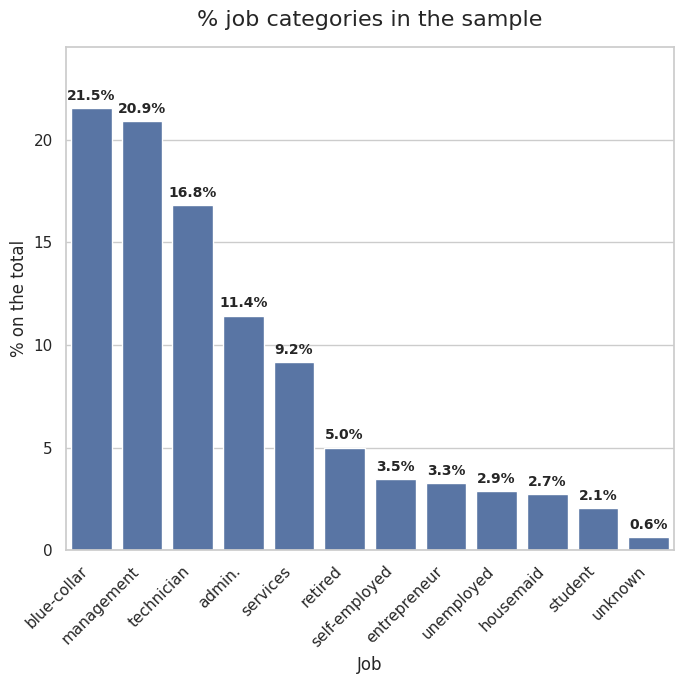

In [67]:
# @title Distribuzione categorie lavorative nel campione
frequenze_percentuali = bank['job'].value_counts(normalize=True) * 100

plt.figure(figsize=(7, 7))
ax = sns.barplot(
    x=frequenze_percentuali.index,
    y=frequenze_percentuali.values,
    legend=False
)

for p in ax.patches:
    altezza = p.get_height()
    if altezza > 0:
        ax.text(
            p.get_x() + p.get_width() / 2.,
            altezza + 0.4,
            f'{altezza:.1f}%',
            ha="center",
            fontsize=10,
            fontweight='bold'
        )


plt.title("% job categories in the sample", fontsize=16, pad=15)
plt.xlabel("Job", fontsize=12)
plt.ylabel("% on the total", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=11)

plt.ylim(0, frequenze_percentuali.max() + 3)

plt.tight_layout()
plt.show()

Il grafico ci mostra la suddivisione del campione in base alla professione.

Come detto in precedenza **operai** e **manager** domininano la clientela della banca (in base al campione selezionato).

##Domanda xx (2.1)

##Quali categorie (lavoro, status civile, istruzione, età) sono più propense ad aprire un conto deposito?

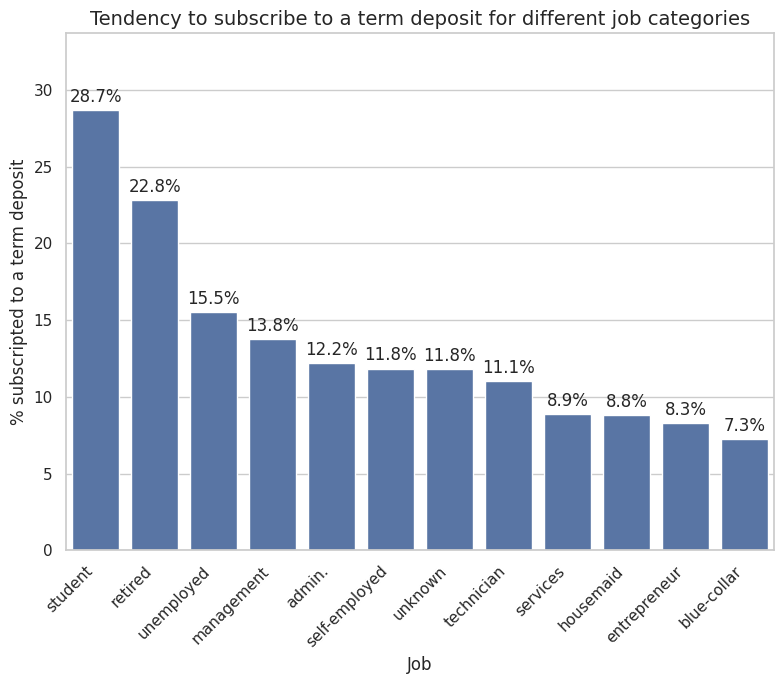

In [68]:
propensione_lavori = (bank.groupby('job')['y']
                      .apply(lambda x: (x == 'yes').mean() * 100)
                      .sort_values(ascending=False))

plt.figure(figsize=(8, 7))

ax = sns.barplot(x=propensione_lavori.index,
                 y=propensione_lavori.values
)

ax.set_ylim(0, propensione_lavori.max() + 5)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.title("Tendency to subscribe to a term deposit for different job categories", fontsize=14)
plt.xlabel("Job", fontsize=12)
plt.ylabel("% subscripted to a term deposit", fontsize=12)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

Gli **studenti** i più propensi ad aprire un conto deposito (28%):

* nella distribuzione del saldo medio annuo sono in mezzo: non hanno grandissime somme (valore massimo circa 24mila euro) ma nemmeno conti fortemente in negativo.

Seguono i **pensionati** (22,8%):

* hanno tendenzialmente disponibilità molto maggiori rispetto alla media (con picchi a 80mila euro).

I meno propensi sono stati gli **operai** (7,3%):

* come osservato, gli operai hanno tendenzialmente saldi più bassi, con una variabilità ridotta rispetto ad altre classi.

Anche gli **imprenditori** che hanno aderito al conto deposito sono stati pochi (8,3%):

* riprendendo quanto detto in precedenza, nonostante essi presentino saldi medi più alti, la mediana ha rivelato che la situazione economica reale va tarata al ribasso.

Sempre intorno a soglie basse di adesione abbiamo casalinghi (8,8%) e lavoratori nei servizi (8,9%).
* si tratta di classi lavorative tendenzialmente più "povere".

/tmp/ipykernel_2133/3565193419.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  propensione_age = (bank.groupby('age_category')['y']


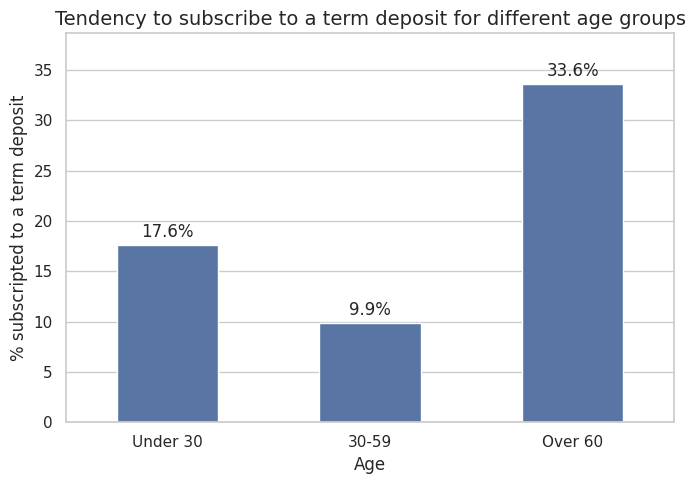

In [69]:
propensione_age = (bank.groupby('age_category')['y']
                      .apply(lambda x: (x == 'yes').mean() * 100)
                      .sort_values(ascending=True))

plt.figure(figsize=(7, 5))
ax = sns.barplot(
    x=propensione_age.index,
    y=propensione_age.values,
    width=0.5
)

ax.set_ylim(0, propensione_age.max() + 5)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.title("Tendency to subscribe to a term deposit for different age groups", fontsize=14)
plt.xlabel("Age", fontsize=12)
plt.ylabel("% subscripted to a term deposit", fontsize=12)

plt.tight_layout()
plt.show()

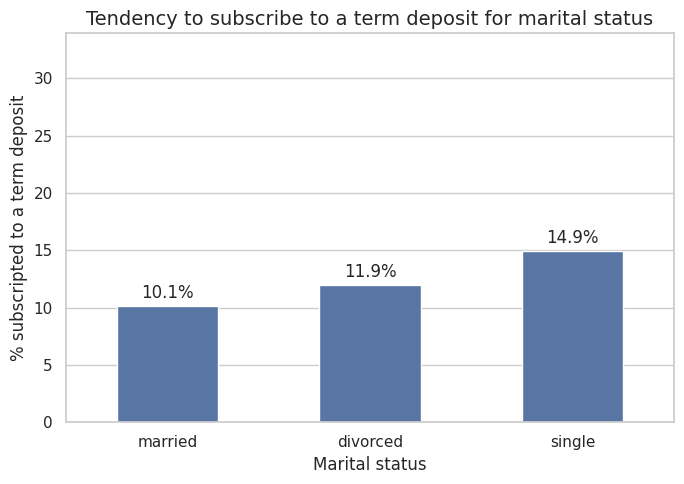

In [70]:
propensione_mar = (bank.groupby('marital')['y']
                      .apply(lambda x: (x == 'yes').mean() * 100)
                      .sort_values(ascending=True))

plt.figure(figsize=(7, 5))
ax = sns.barplot(
    x=propensione_mar.index,
    y=propensione_mar.values,
    width=0.5
)

ax.set_ylim(0, propensione_age.max() + 0.3)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.title("Tendency to subscribe to a term deposit for marital status", fontsize=14)
plt.xlabel("Marital status", fontsize=12)
plt.ylabel("% subscripted to a term deposit", fontsize=12)

plt.tight_layout()
plt.show()

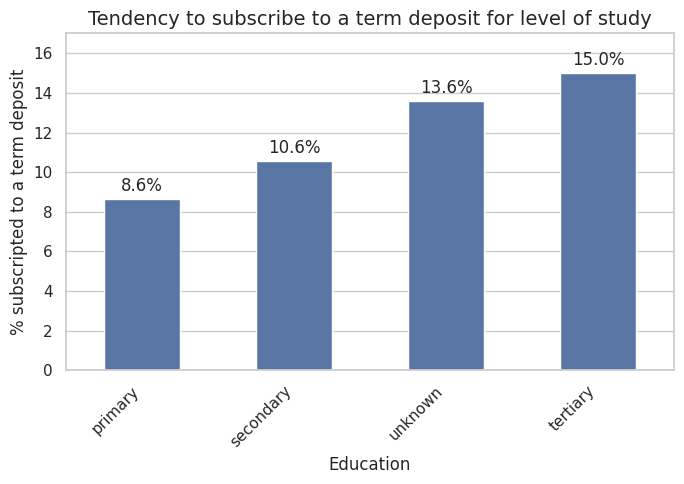

In [71]:
propensione_ed = (bank.groupby('education')['y']
                      .apply(lambda x: (x == 'yes').mean() * 100)
                      .sort_values(ascending=True))

plt.figure(figsize=(7, 5))
ax = sns.barplot(
    x=propensione_ed.index,
    y=propensione_ed.values,
    width=0.5
)

ax.set_ylim(0, propensione_ed.max() + 2)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.title("Tendency to subscribe to a term deposit for level of study", fontsize=14)
plt.xlabel("Education", fontsize=12)
plt.ylabel("% subscripted to a term deposit", fontsize=12)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

## Domanda xx (2.2)

## Il saldo in banca influenza l'iscrizione ad un conto deposito?

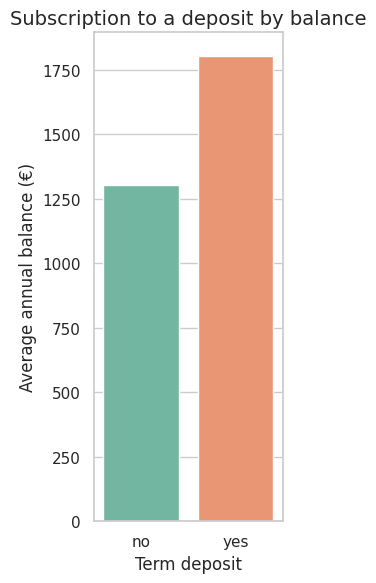

In [100]:
# @title Sottoscrizione a conto deposito (y) in base alla giacenza media
plt.figure(figsize=(3,6))
sns.barplot(data=bank,
            x='y',
            y='balance',
            palette='Set2',
            hue='y',
            errorbar=None)


plt.title("Subscription to a deposit by balance", fontsize=14)
plt.xlabel('Term deposit', fontsize=12)
plt.ylabel('Average annual balance (€)', fontsize=12)
#plt.legend(fontsize=8, loc='upper left')

plt.tight_layout()
plt.show()

Notiamo che tendenzialmente chi sottoscrive un conto deposito ha una giacenza media annua **più alta** (circa 500 euro di differenza).

Proviamo a visualizzare la distribuzione della giacenza media.

(-2000.0, 10000.0)

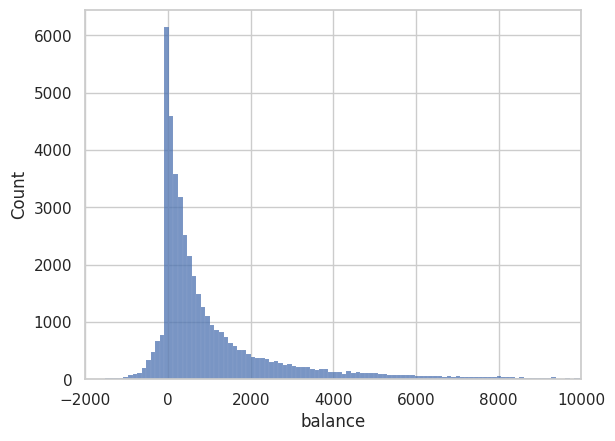

In [104]:
# @title Distribuzione giacenza media annua nel campione (I)
sns.histplot(data=bank, x='balance', bins=1000)
plt.xlim(-2000, 10000)


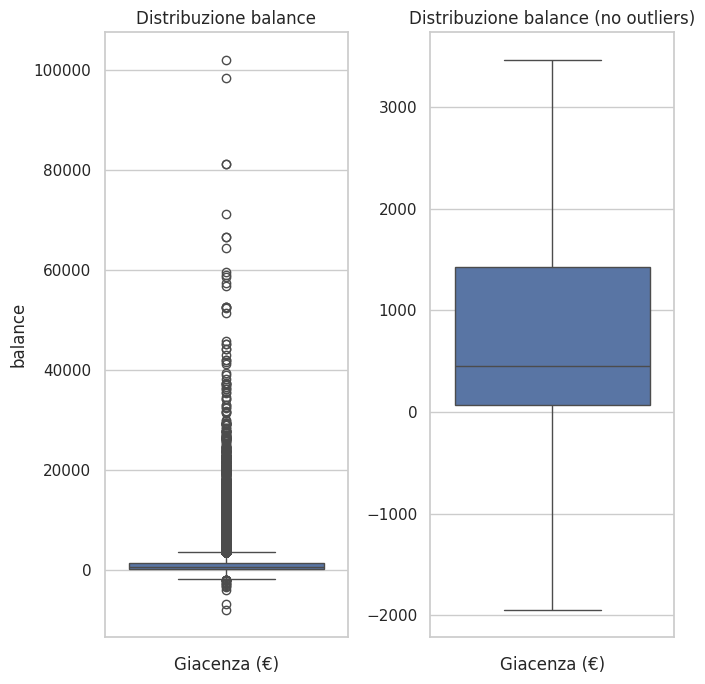

In [74]:
# @title Distribuzione giacenza media annua nel campione (II)
fig, axes = plt.subplots(1, 2, figsize=(7, 7))
sns.boxplot(data=bank, y='balance', ax=axes[0])
axes[0].set_title('Distribuzione balance')
axes[0].set_xlabel('Giacenza (€)')

sns.boxplot(data=bank, y='balance', showfliers=False, ax=axes[1])
axes[1].set_title('Distribuzione balance (no outliers)')
axes[1].set_xlabel('Giacenza (€)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

Qui invece vediamo la **distribuzione della giacenza media annua**:
* notiamo che la mediana è inferiore alla media

* notiamo la presenza di numerosi outlier superiori alla media (casi di saldi molto alti che influiscono sulla media, alzandola).

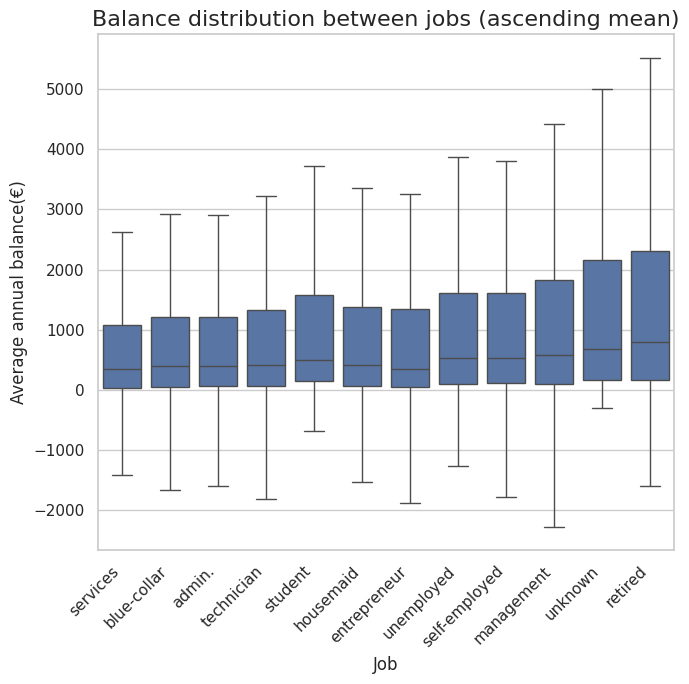

In [75]:
ordine_lavori = bank.groupby('job')['balance'].mean().sort_values().index

plt.figure(figsize=(7, 7))
sns.boxplot(data=bank,
            x='job',
            y='balance',
            order=ordine_lavori,
            showfliers=False),
#plt.ylim(-2000, 10000) #per migliorare la visualizzazione, soglie limite
plt.title("Balance distribution between jobs (ascending mean)", fontsize=16)
plt.xlabel("Job", fontsize=12)
plt.ylabel("Average annual balance(€)", fontsize=12)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()


In [76]:
bank.groupby(['job'])['balance'].describe()

,count,mean,std,min,25%,50%,75%,max
job,,,,,,,,
admin.,5171.0,1135.838909,2641.962686,-1601.0,63.00,396.0,1203.00,64343.0
blue-collar,9732.0,1078.826654,2240.523208,-8019.0,55.00,388.0,1203.00,66653.0
entrepreneur,1487.0,1521.470074,4153.442626,-2082.0,44.50,352.0,1341.00,59649.0
housemaid,1240.0,1392.395161,2984.692098,-1941.0,57.75,406.0,1382.75,45141.0
management,9458.0,1763.616832,3822.965605,-6847.0,98.00,572.0,1825.00,102127.0
retired,2264.0,1984.215106,4397.044177,-1598.0,164.50,787.0,2309.00,81204.0
self-employed,1579.0,1647.970868,3684.259573,-3313.0,120.00,526.0,1603.50,52587.0
services,4154.0,997.088108,2164.493505,-2122.0,35.00,339.5,1071.75,57435.0
student,938.0,1388.060768,2441.703526,-679.0,148.25,502.0,1579.75,24025.0


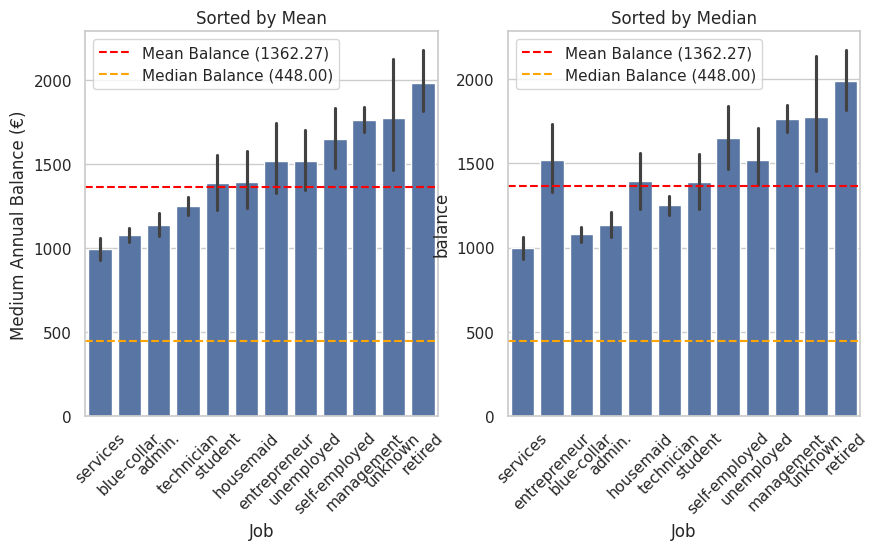

media giacenza nel campione 1362.27
mediana 448.0


In [77]:
# @title Distribuzione giacenza tra le categorie lavorative
ordine_lavori_media = bank.groupby('job')['balance'].mean().sort_values().index

ordine_lavori_mediana = bank.groupby('job')['balance'].median().sort_values().index

balance_mean = bank['balance'].mean()
balance_median = bank['balance'].median()

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
sns.barplot(data=bank, x='job', y='balance',
            order=ordine_lavori_media, ax=axs[0])
axs[0].axhline(balance_mean, color='red', linestyle='--',
               label=f'Mean Balance ({balance_mean:.2f})')
axs[0].axhline(balance_median, color='orange', linestyle='--',
               label=f'Median Balance ({balance_median:.2f})')
axs[0].set_title("Sorted by Mean")
axs[0].set_xlabel("Job")
axs[0].set_ylabel("Medium Annual Balance (€)")
axs[0].tick_params(axis='x', rotation=45)
axs[0].legend()


sns.barplot(data=bank, x='job', y='balance',
            order=ordine_lavori_mediana, ax=axs[1])
axs[1].axhline(balance_mean, color='red', linestyle='--',
               label=f'Mean Balance ({balance_mean:.2f})')
axs[1].axhline(balance_median, color='orange', linestyle='--',
               label=f'Median Balance ({balance_median:.2f})')

axs[1].set_title("Sorted by Median")
axs[1].set_xlabel("Job")
axs[1].tick_params(axis='x', rotation=45)
axs[1].legend()

plt.show()

print("media giacenza nel campione", balance_mean.round(2))
print("mediana", balance_median)

Notiamo che valore mediano e media differiscono in specifiche categorie lavorative per quanto riguarda la variabile '*balance*':
* gli **imprenditori**
* i **casalinghi**
* i **lavoratori autonomi**

Il caso che stupisce maggiormente è quello degli imprenditori, che nonostante presentino un saldo più alto della media, hanno in realtà saldi molto più bassi (sono penultimi nella distribuzione in base alla mediana).

Al primo posto si riaffermano i pensionati, con saldo medio più alto di tutte le categorie.

In [192]:
bank["education"].value_counts(normalize=True)

,proportion
education,
secondary,0.513194
tertiary,0.294198
primary,0.151534
unknown,0.041074


In [193]:
uno = bank.groupby(bank["job"])["education"]
print(uno.value_counts(normalize=True).unstack())

education       primary  secondary  tertiary   unknown
job                                                   
admin.         0.040418   0.815896  0.110617  0.033069
blue-collar    0.386149   0.551891  0.015310  0.046650
entrepreneur   0.123067   0.364492  0.461332  0.051110
housemaid      0.505645   0.318548  0.139516  0.036290
management     0.031085   0.118524  0.824804  0.025587
retired        0.351148   0.434629  0.161661  0.052562
self-employed  0.082331   0.365421  0.527549  0.024699
services       0.083052   0.832210  0.048628  0.036110
student        0.046908   0.541578  0.237740  0.173774
technician     0.020798   0.688298  0.259050  0.031855
unemployed     0.197237   0.558711  0.221796  0.022256
unknown        0.177083   0.246528  0.135417  0.440972


## Domanda 2.5? Ma anche no

Grafico per giacenza media e tipo di contatto, con la sottoscrizione del conto deposito.

<Axes: xlabel='contact', ylabel='balance'>

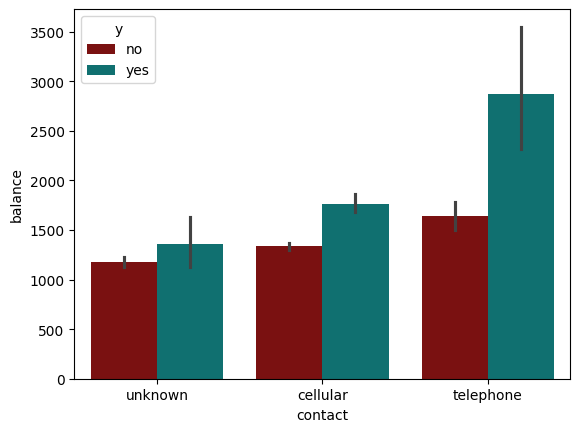

In [64]:
sns.barplot(x="contact", y="balance", hue="y",  data=bank, palette = {"no":"darkred", "yes": "teal"})

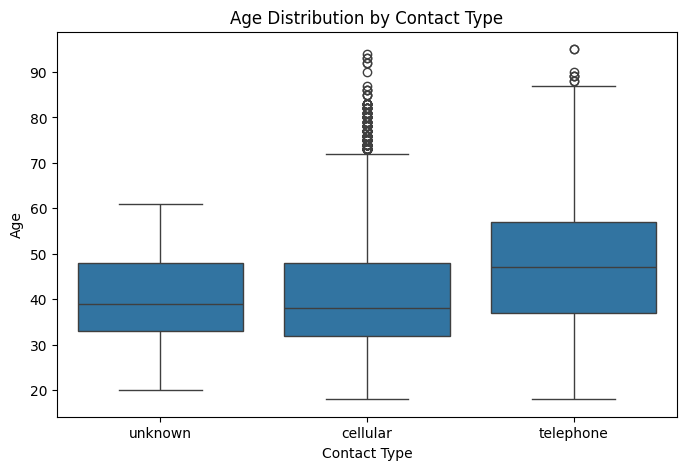

In [65]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='contact', y='age', data=bank)
plt.title('Age Distribution by Contact Type')
plt.xlabel('Contact Type')
plt.ylabel('Age')
plt.show()

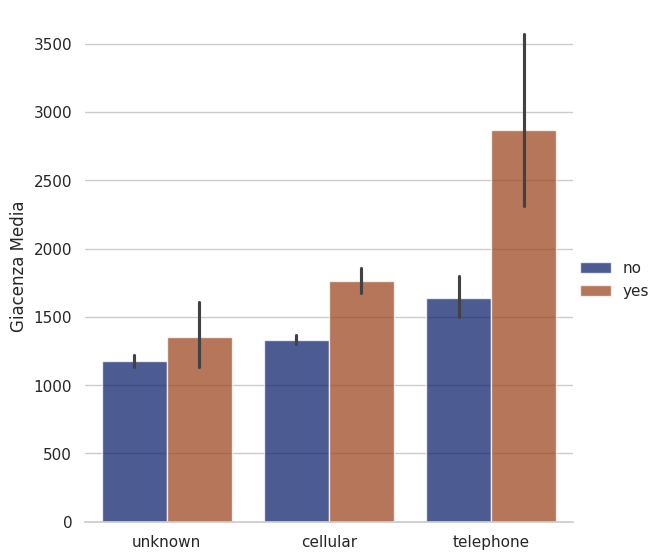

In [66]:
sns.set_theme(style="whitegrid")

g = sns.catplot(
    data=bank, kind="bar",
    x="contact", y="balance", hue="y", palette="dark", alpha=.75, height=6
)
g.despine(left=True)
g.set_axis_labels("", "Giacenza Media")
g.legend.set_title("")

## Domanda 2.3?

Come varia il successo della campagna marketing a seconda del numero di contatti effettuati e secondo l'esito della campagna precedente?

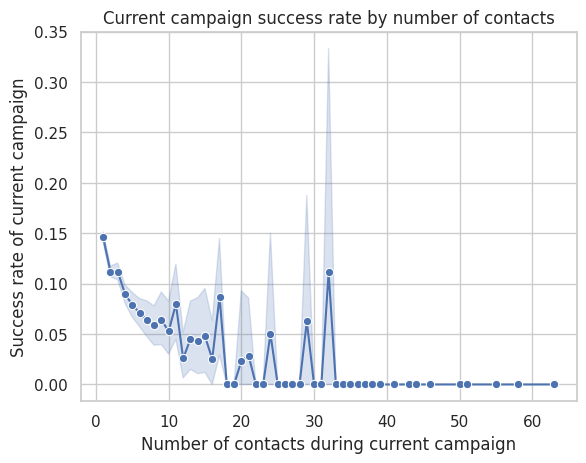

In [78]:
sns.lineplot(data=bank, x="campaign", y="y_numeric", marker="o", errorbar=("ci", 95))
#Media di y_numeric indica il success rate
plt.xlabel("Number of contacts during current campaign")
plt.ylabel("Success rate of current campaign")
plt.title("Current campaign success rate by number of contacts")
plt.show()

Il tasso di successo risulta massimo per i primi 1-3 contatti. Come già evidenziato dai dati in precedenza, possiamo vedere come un maggior numero di contatti nell'attuale campagna è associato a un successo decrescente. In particolare, oltre i 35 contatti circa, il tasso di successo è pari a 0.

Contatti ripetuti non aumentano dunque il tasso di successo. Al contrario, un numero elevato di contatti potrebbe indicare che si tratta di clienti più difficili da convincere.

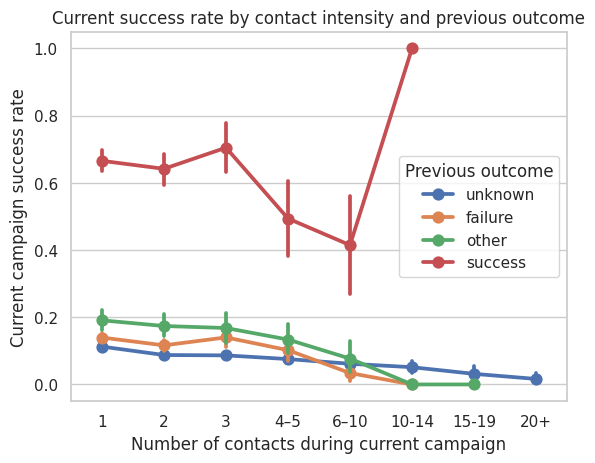

In [79]:
bank["campaign_group"] = pd.cut(
    bank["campaign"],
    bins=[0, 1, 2, 3, 5, 10, 15, 20, bank["campaign"].max()],
    labels=["1", "2", "3", "4–5", "6–10", "10-14", "15-19", "20+"]
)
# li unisco perché success aveva dei valori estremi e non era ben leggibile

sns.pointplot(data=bank, x="campaign_group", y="y_numeric", hue="poutcome", errorbar=("ci", 95))

plt.xlabel("Number of contacts during current campaign")
plt.ylabel("Current campaign success rate")
plt.title("Current success rate by contact intensity and previous outcome")
plt.legend(title = "Previous outcome")
plt.show()

Differenziando i clienti in base all'esito della precedente campagna marketing, notiamo delle notevoli differenze sia nell'efficacia dei contatti che nel tasso di successo.

I clienti che già hanno sottoscritto un conto deposito hanno tassi di successo molto più alti rispetto agli altri gruppi. Il precedente successo è un forte predittivo per il successo nella campagna attuale.

Invece, clienti con precedenti esiti negativi, diversi o ignoti mostrano un tasso di successo molto più basso. Inoltre, tra questi gruppi, il tasso di successo diminuisce con l'aumentare del numero dei contatti.

Nota: il tasso di successo tra i clienti che hanno già sottoscritto un conto deposito in precedenza arriva al 100% con un numero di contatti tra 10 e 14. Plausibilmente, si tratta di un campione di clienti molto ridotto.

Tutto sommato, sembra più efficace indirizzare gli sforzi verso clienti già 'affezionati' rispetto a insistere nel contattare coloro che hanno già risposto 'no' varie volte.

## Domanda 2.4?

Come varia la durata delle chiamate in base al periodo?

In [80]:
bank = bank.reset_index(drop=True) # per resettare l'indice

bank["month_index"] = (bank["month"] != bank["month"].shift()).cumsum()

Periodi con chiamate più lunghe hanno avuto tasso di successo più alto?



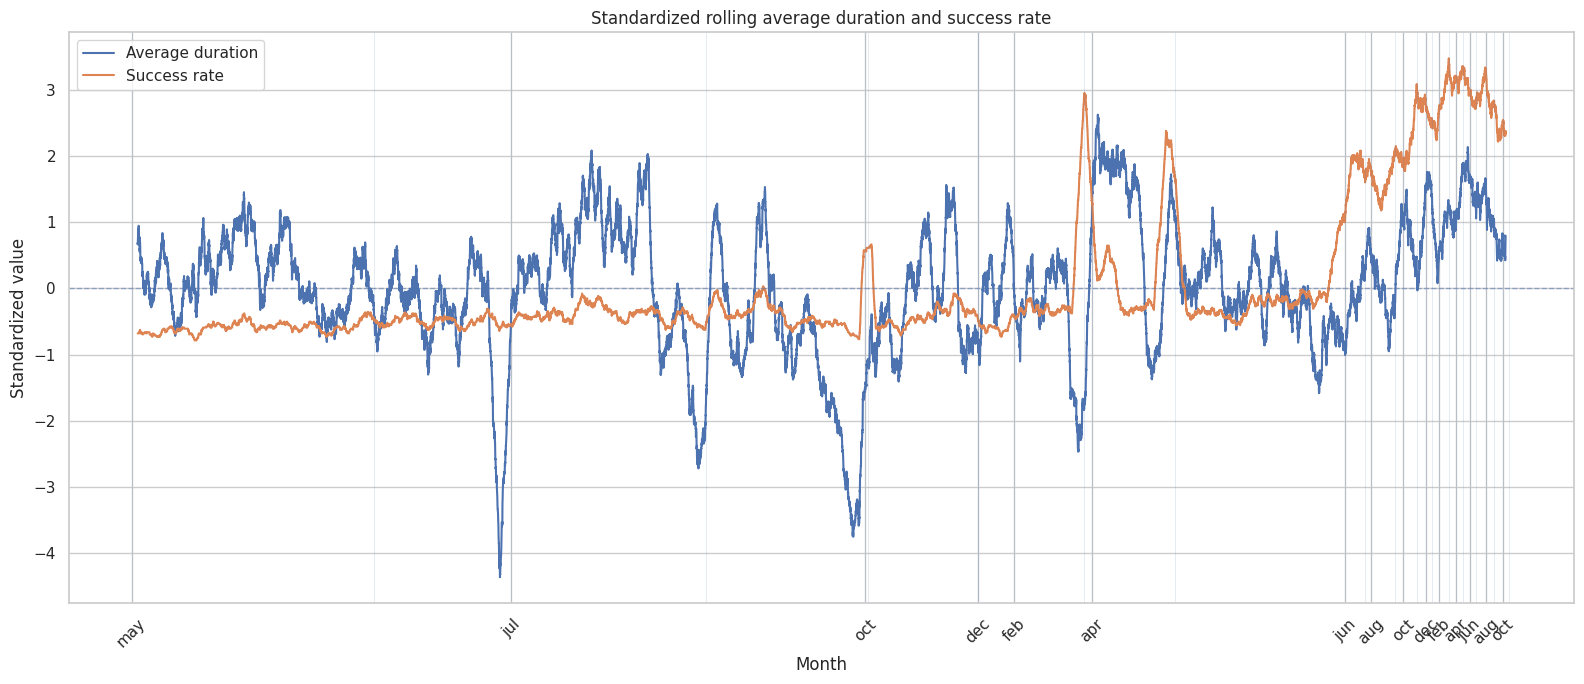

In [154]:
bank["rolling_duration"] = bank["duration"].rolling(window=400, center=True).mean()
bank["rolling_success"] = bank["y_numeric"].rolling(window=400, center=True).mean()

bank["duration_z"] = (bank["rolling_duration"] - bank["rolling_duration"].mean()) / bank["rolling_duration"].std()
bank["success_z"] = (bank["rolling_success"] - bank["rolling_success"].mean()) / bank["rolling_success"].std()

plt.figure(figsize=(16,7))

plt.plot(bank.index, bank["duration_z"], linewidth=1.5, label="Average duration")
plt.plot(bank.index, bank["success_z"], linewidth=1.5, label="Success rate")

month_starts = bank.groupby("month_index").head(1).index
month_labels = bank.loc[month_starts, "month"]

for x in month_starts:
    plt.axvline(x=x, linewidth=0.5, alpha=0.2)

plt.xticks(month_starts[::2], month_labels[::2], rotation=45)

plt.axhline(0, linestyle="--", linewidth=1, alpha=0.5)

plt.ylabel("Standardized value")
plt.xlabel("Month")
plt.title("Standardized rolling average duration and success rate")
plt.legend()
plt.tight_layout()
plt.show()

Per la maggior parte della campagna non emerge una chiara associazione tra durata media delle chiamate e tasso di successo. Una tendenza positiva comune si osserva soltanto nella fase finale, dove entrambe le serie registrano un incremento simultaneo.

Consideriamo invece come varia la durata delle chiamate guardando all'esito della campagna marketing.

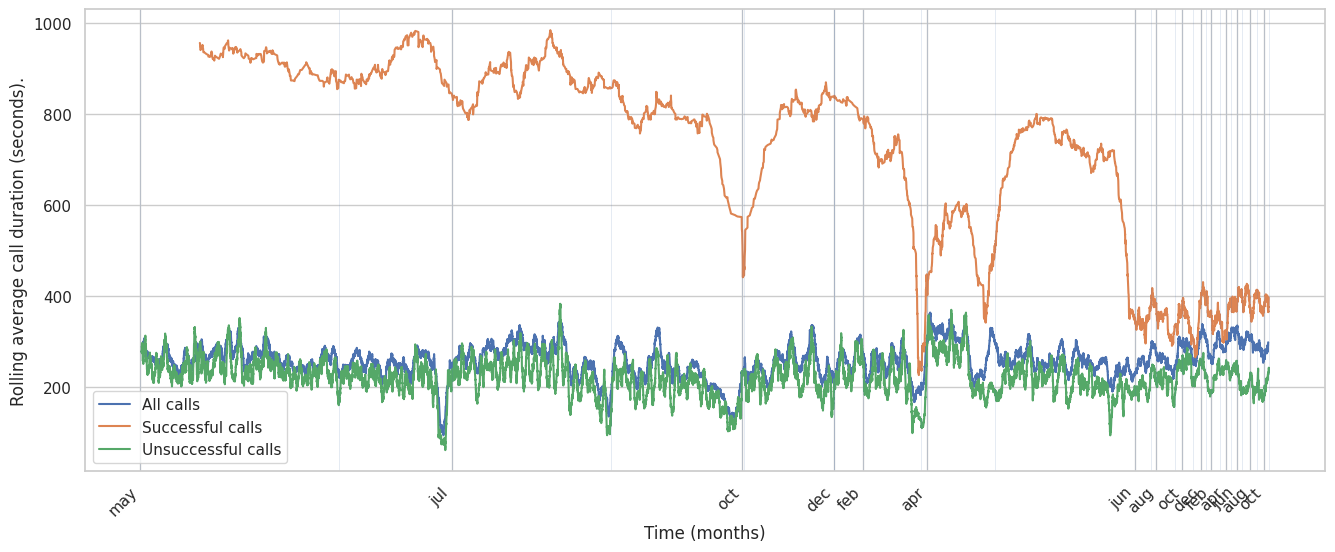

In [155]:

success = bank[bank["y_numeric"] == 1]
failure = bank[bank["y_numeric"] == 0]

plt.figure(figsize=(16,6))

plt.plot(bank["duration"].rolling(250, center=True).mean(),
         label="All calls")

plt.plot(success["duration"].rolling(100, center=True).mean(),
         label="Successful calls")

plt.plot(failure["duration"].rolling(100, center=True).mean(),
         label="Unsuccessful calls")

month_starts = bank.groupby("month_index").head(1).index
month_labels = bank.loc[month_starts, "month"].astype(str)

for x in month_starts:
    plt.axvline(x=x, linewidth=0.5, alpha=0.2)
# Display every second month label to reduce clutter
plt.xticks(month_starts[::2], month_labels[::2], rotation=45, ha='right') # Use month names and rotate labels

#plt.axhline(y=bank["duration"].mean(), color='red', linestyle='--', alpha=0.5) non ci sta molto

plt.ylabel("Rolling average call duration (seconds).")
plt.xlabel("Time (months)")
plt.legend()

Il grafico evidenzia che le chiamate che portano alla sottoscrizione del conto deposito sono mediamente più lunghe di quelle non di successo per tutto il periodo di osservazione. La durata media delle chiamate a esito positivo mostra inoltre una maggiore variabilità temporale, tendendo a decrescere verso la fine della campagna.
Le chiamate con esito negativo mantengono una durata più stabile ma su livelli nettamente inferiori.

La durata media si colloca tra i due andamenti, ma più vicina alle chiamate con esito negativo, che rappresentano difatti la maggioranza dei contatti.

In [120]:
monthly_contacts = bank.groupby("month_index")["y_numeric"].count()

comparison = pd.DataFrame({
    "period": ["First 12 months", "Following months"],
    "mean_monthly_contacts": [
        monthly_contacts.loc[1:12].mean(),
        monthly_contacts.loc[13:].mean()
    ],
    "total_contacts": [
        monthly_contacts.loc[1:12].sum(),
        monthly_contacts.loc[13:].sum()
    ]
})

print(comparison)

             period  mean_monthly_contacts  total_contacts
0   First 12 months            3312.666667           39752
1  Following months             303.277778            5459


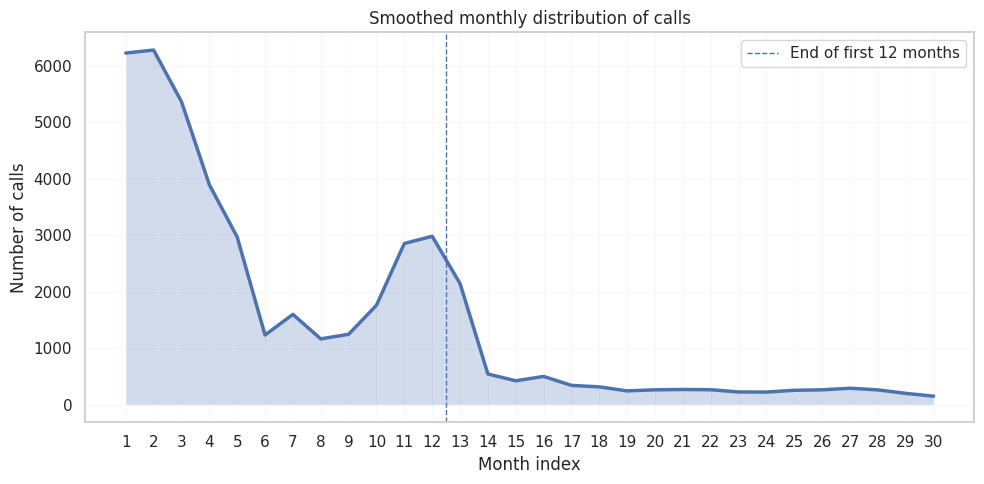

In [168]:
monthly_calls = bank.groupby("month_index").size().reset_index(name="calls")

monthly_calls["calls_smooth"] = (
    monthly_calls["calls"]
    .rolling(window=3, center=True, min_periods=1)
    .mean()
)

plt.figure(figsize=(10,5))

plt.fill_between(
    monthly_calls["month_index"],
    monthly_calls["calls_smooth"],
    alpha=0.25
)

plt.plot(
    monthly_calls["month_index"],
    monthly_calls["calls_smooth"],
    linewidth=2.5
)

plt.axvline(12.5, linestyle="--", linewidth=1, label="End of first 12 months")

plt.xticks(monthly_calls["month_index"])
plt.xlabel("Month index")
plt.ylabel("Number of calls")
plt.title("Smoothed monthly distribution of calls")

plt.grid(alpha=0.2, linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()

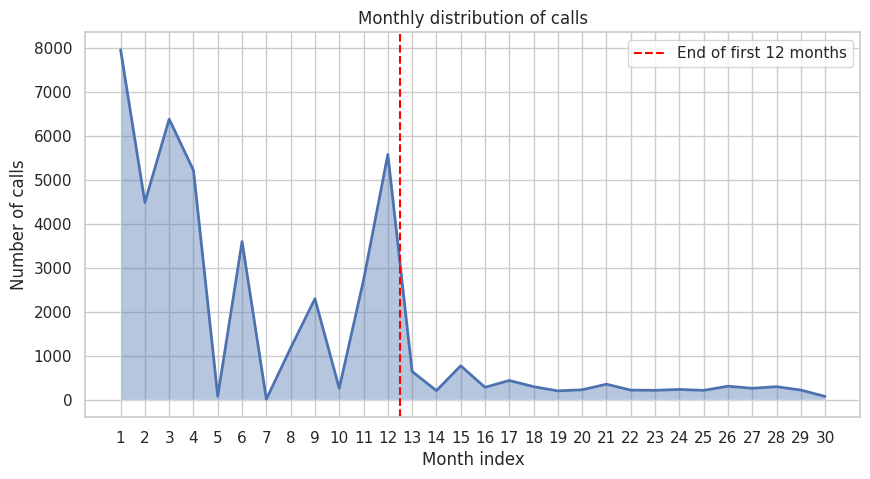

In [164]:
monthly_calls = bank.groupby("month_index").size().reset_index(name="calls")

plt.figure(figsize=(10,5))

plt.fill_between(
    monthly_calls["month_index"],
    monthly_calls["calls"],
    alpha=0.4
)

plt.plot(
    monthly_calls["month_index"],
    monthly_calls["calls"],
    linewidth=2
)

plt.axvline(12.5, linestyle="--", color="red", label="End of first 12 months")

plt.xticks(monthly_calls["month_index"])
plt.xlabel("Month index")
plt.ylabel("Number of calls")
plt.title("Monthly distribution of calls")
plt.legend()

plt.show()

Da questi dati si osserva che la distribuzione dei contatti effettuati è fortemente sbilanciata nel tempo. La maggior parte delle chiamate è concentrata nel primo anno, con una media di oltre 3.000 al mese, mentre nei mesi successivi il numero di osservazioni si riduce sensibilmente, attestandosi su poche centinaia di osservazioni al mese.

Pertanto, le stime relative all'ultima parte della campagna potrebbero essere influenzate dalla ridotta numerosità del campione, e quindi devono essere interpretate con maggior cautela.

In [86]:
# Create a mapping from month_index to month name
month_index_to_name = bank[['month_index', 'month']].drop_duplicates().set_index('month_index')['month']

# Convert the success_rate_by_month_index Series to a DataFrame for easier merging
success_rate_df = success_rate_by_month_index.reset_index()
success_rate_df.columns = ['month_index', 'success_rate']

# Merge with the month names and sort by success rate
success_rate_with_names = success_rate_df.merge(month_index_to_name.rename('month'), left_on='month_index', right_index=True)
#success_rate_with_names = success_rate_with_names.sort_values(by='success_rate', ascending=False)

success_rate_with_names.head(30)

,month_index,success_rate,month
0,1,0.032424,may
1,2,0.044806,jun
2,3,0.060188,jul
3,4,0.055225,aug
4,5,0.612500,oct
5,6,0.061145,nov
6,7,0.076923,dec
7,8,0.032313,jan
8,9,0.111063,feb
9,10,0.484496,mar


# Fase 3

## 3.1 Preparazione - da commentare

In [209]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)


Ricarichiamo il dataset senza modifiche

In [208]:
bank_mod = pd.read_csv("Bank_Marketing.csv", sep=";")
print (bank_mod)

       age           job   marital  education default  balance housing loan  \
0       58    management   married   tertiary      no     2143     yes   no   
1       44    technician    single  secondary      no       29     yes   no   
2       33  entrepreneur   married  secondary      no        2     yes  yes   
3       47   blue-collar   married    unknown      no     1506     yes   no   
4       33       unknown    single    unknown      no        1      no   no   
...    ...           ...       ...        ...     ...      ...     ...  ...   
45206   51    technician   married   tertiary      no      825      no   no   
45207   71       retired  divorced    primary      no     1729      no   no   
45208   72       retired   married  secondary      no     5715      no   no   
45209   57   blue-collar   married  secondary      no      668      no   no   
45210   37  entrepreneur   married  secondary      no     2971      no   no   

         contact  day month  duration  campaign  pd

In [210]:
bank_mod.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


Sono variabili categoriche ordinali: education, month

Sono variabili categoriche nominali: job, marital, contact, poutcome

Sono numeriche: age, balance, day, duration, campaign, pdays, previous

Sono dicotomiche yes/no: default, housing, loan, y

In [211]:
# @title Variabili no/yes a 0/1
bank_mod['y'] = bank_mod['y'].map({'no': 0, 'yes': 1})
bank_mod['default'] = bank_mod['default'].map({'no': 0, 'yes': 1})
bank_mod['housing'] = bank_mod['housing'].map({'no': 0, 'yes': 1})
bank_mod['loan'] = bank_mod['loan'].map({'no': 0, 'yes': 1})

Trasformo le variabili categoriali in numeriche.

In [212]:
bank_mod["month"] = (bank_mod["month"] != bank_mod["month"].shift()).cumsum()

In [213]:
# Ordinale per 'education'
education_mapping = {
    'unknown': 0,
    'primary': 1,
    'secondary': 2,
    'tertiary': 3
}

bank_mod['education'] = bank_mod['education'].map(education_mapping)

# One-hot encoding for nominal categorical variables
bank_mod = pd.get_dummies(bank_mod, columns=['job', 'marital', 'contact', 'poutcome'], drop_first=False) #ho modificat anche qui drop_first=True

In [214]:
display(bank_mod.head())

,age,education,default,balance,housing,loan,day,month,duration,campaign,...,marital_divorced,marital_married,marital_single,contact_cellular,contact_telephone,contact_unknown,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
0,58,3,0,2143,1,0,5,1,261,1,...,False,True,False,False,False,True,False,False,False,True
1,44,2,0,29,1,0,5,1,151,1,...,False,False,True,False,False,True,False,False,False,True
2,33,2,0,2,1,1,5,1,76,1,...,False,True,False,False,False,True,False,False,False,True
3,47,0,0,1506,1,0,5,1,92,1,...,False,True,False,False,False,True,False,False,False,True
4,33,0,0,1,0,0,5,1,198,1,...,False,False,True,False,False,True,False,False,False,True


Dividiamo i dati in training set e test set.

In [215]:
X = bank_mod.drop(columns=['y'])
y = bank_mod['y']

In [216]:
X_train, X_test, y_train, y_test = train_test_split( # funzione che ci produce i 4 risultati; in questo caso i 70% su cui apprendere e i
                                                    #30% da testare, mettendo la classe colonna nei rispettivi y
                                                     #ce li restituisce i quest'ordine
    X,
    y, #colonna classe 0/1
    test_size=0.30,
    random_state=42, #utile mischiare i dati ché magari sono ordinati
    stratify=y #ti passo la colonna y; mischiali così che la proporzione sia rappresentata sia in test che train (Es. avere 60% ben e 40% mal in entrambi)
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (31647, 34)
Test set: (13564, 34)


In [217]:
X_test.head()

,age,education,default,balance,housing,loan,day,month,duration,campaign,...,marital_divorced,marital_married,marital_single,contact_cellular,contact_telephone,contact_unknown,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
37735,40,2,0,973,0,0,14,12,449,1,...,True,False,False,True,False,False,False,False,False,True
44332,35,3,0,154,0,0,29,26,200,4,...,False,False,True,True,False,False,True,False,False,False
4432,38,2,0,736,1,0,20,1,775,1,...,False,True,False,False,False,True,False,False,False,True
38725,35,2,0,205,1,1,15,12,1313,7,...,False,True,False,True,False,False,True,False,False,False
38581,44,2,0,532,1,0,15,12,550,2,...,False,False,True,True,False,False,True,False,False,False


In [219]:
print("Numero osservazioni:", X.shape[0])
print("Numero feature:", X.shape[1])

Numero osservazioni: 45211
Numero feature: 34


## 3.2 Regressione Logistica

## 3.3 k-NN

## 3.4 Random Forest

In [262]:
rf = RandomForestClassifier(
    n_estimators=200, #quanti alberi
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

acc_rf = accuracy_score(y_test, pred_rf)

print(f"Accuracy Random Forest: {acc_rf:.3f}")

Accuracy Random Forest: 0.911


** ha impiegato 16.6s alle 21:29 del 08/07/2025

accuracy 0.911

con 400 è venuto leggermente meno. e pure con 300 e 150. Con 500 viene 0.910

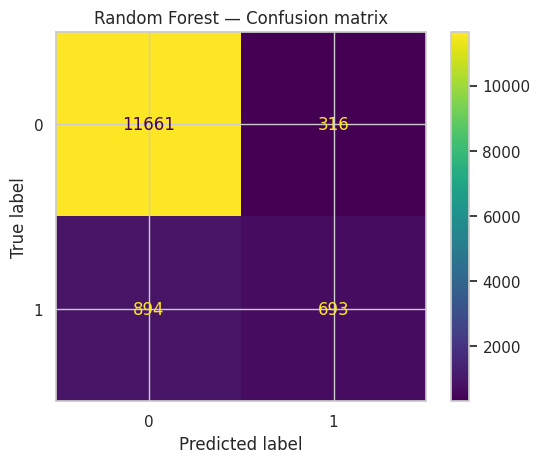

In [263]:
cm_rf = confusion_matrix(y_test, pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf
)

disp.plot()
plt.title("Random Forest — Confusion matrix")
plt.show()

In [264]:
print(classification_report(
    y_test,
    pred_rf,
))

              precision    recall  f1-score   support

           0       0.93      0.97      0.95     11977
           1       0.69      0.44      0.53      1587

    accuracy                           0.91     13564
   macro avg       0.81      0.71      0.74     13564
weighted avg       0.90      0.91      0.90     13564



---


In [242]:
#trees_values = [30, 50, 100, 150, 200, 300, 500, 750, 1000]

#results = []

#for tree in trees_values:
 # model_rf = RandomForestClassifier(n_estimators=tree, random_state=5) #METTO 42 PER CONSISTENCY
  #model_rf.fit(X_train, y_train)
  #pred_rf = model_rf.predict(X_test) # Corrected line
  #acc_rf = accuracy_score(y_test, pred_rf)
  #results.append({"trees": tree, "accuracy": acc_rf})

#rf_results = pd.DataFrame(results)
#rf_results

,trees,accuracy
0,30,0.906149
1,50,0.906886
2,100,0.907623
3,150,0.908655
4,200,0.909024
5,300,0.908950
6,500,0.909835
7,750,0.909982
8,1000,0.910130


Ci ha messo 175s. L'accuratezza non cambia troppo all'aumentare degli alberi, quindi bastano pochi alberi.

30: 0.906
50: 0.907
100:0.908
150: 0.909
200: 0.909
300: 0.9098
500: 0.9099
1000: 0.91


trees	accuracy
ì

0	30	0.906149
1	50	0.906886
2	100	0.907623
3	150	0.908655
4	200	0.909024
5	300	0.908950
6	500	0.909835
7	750	0.909982
8	1000	0.910130


Sulla base del grafico dopo punterei su 200 o 500

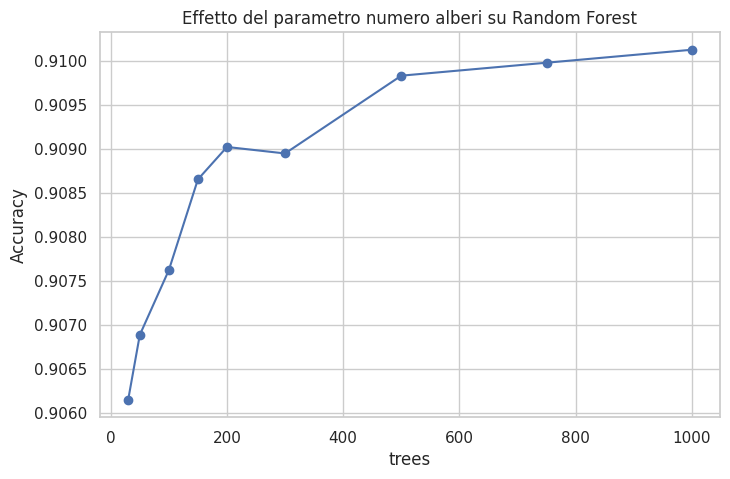

In [246]:
plt.figure(figsize=(8,5))
plt.plot(rf_results["trees"], rf_results["accuracy"], marker="o")
plt.xlabel("trees")
plt.ylabel("Accuracy")
plt.title("Effetto del parametro numero alberi su Random Forest")
plt.show()

1


## 3.4.2 o 3.5? Feature Importance

In [265]:
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
})

importance = importance.sort_values("importance", ascending=False)

importance.head(10)

,feature,importance
8,duration,0.278122
7,month,0.157075
3,balance,0.095702
0,age,0.086722
6,day,0.080180
9,campaign,0.037985
32,poutcome_success,0.034737
10,pdays,0.032145
1,education,0.024312
11,previous,0.018599


In [267]:
importance.tail(10)

,feature,importance
17,job_retired,0.004795
20,job_student,0.004273
18,job_self-employed,0.004216
22,job_unemployed,0.004180
28,contact_telephone,0.003937
31,poutcome_other,0.003542
15,job_housemaid,0.003531
14,job_entrepreneur,0.003522
2,default,0.001678
23,job_unknown,0.001280


## prova 2 rf

In [291]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X,
    y, #colonna classe 0/1
    test_size=0.90,
    random_state=42, #utile mischiare i dati ché magari sono ordinati
    stratify=y #ti passo la colonna y; mischiali così che la proporzione sia rappresentata sia in test che train (Es. avere 60% ben e 40% mal in entrambi)
)

print("Training set:", X_train2.shape)
print("Test set:", X_test2.shape)

Training set: (4521, 34)
Test set: (40690, 34)


In [292]:
rf2 = RandomForestClassifier(
    n_estimators=200, #quanti alberi
    random_state=42
)

rf2.fit(X_train2, y_train2)

pred_rf2 = rf.predict(X_test2)

acc_rf2 = accuracy_score(y_test2, pred_rf2)

print(f"Accuracy Random Forest: {acc_rf2:.3f}")

Accuracy Random Forest: 0.970


In [293]:
print(classification_report(
    y_test2,
    pred_rf2,
))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98     35930
           1       0.92      0.81      0.86      4760

    accuracy                           0.97     40690
   macro avg       0.95      0.90      0.92     40690
weighted avg       0.97      0.97      0.97     40690



# Conclusioni